In [1]:
import sys
print(sys.executable)

C:\Users\duyif\miniconda3\envs\pytorch_new\python.exe


In [1]:
from pathlib import Path
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path(r"D:\biosignal-data\WAY-EEG-GAL\P1")
hs = loadmat(
    data_dir / "HS_P1_S1.mat",
    struct_as_record=False,
    squeeze_me=True
)["hs"]

print("受试者：", hs.participant, "记录序号：", hs.series)
print("EEG：", hs.eeg.sig.shape, "采样率：", hs.eeg.samplingrate)
print("运动学：", hs.kin.sig.shape, "采样率：", hs.kin.samplingrate)

受试者： 1 记录序号： 1
EEG： (119496, 32) 采样率： 500
运动学： (119496, 36) 采样率： 500


In [2]:
eeg_names = list(hs.eeg.names)
kin_names = list(hs.kin.names)

print("EEG 通道：", eeg_names)
print("C3 的列号：", eeg_names.index("C3"))

for name in ("Px4", "Py4", "Pz4"):
    matches = [(i, n) for i, n in enumerate(kin_names) if str(n).startswith(name + " ")]
    print(name, matches)

EEG 通道： ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']
C3 的列号： 12
Px4 [(21, 'Px4 - position x sensor 4')]
Py4 [(25, 'Py4 - position y sensor 4')]
Pz4 [(29, 'Pz4 - position z sensor 4')]


In [5]:
from matplotlib import font_manager

font_path = r"C:\Windows\Fonts\msyh.ttc"  # Windows 的微软雅黑
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(
    fname=font_path
).get_name()
plt.rcParams["axes.unicode_minus"] = False

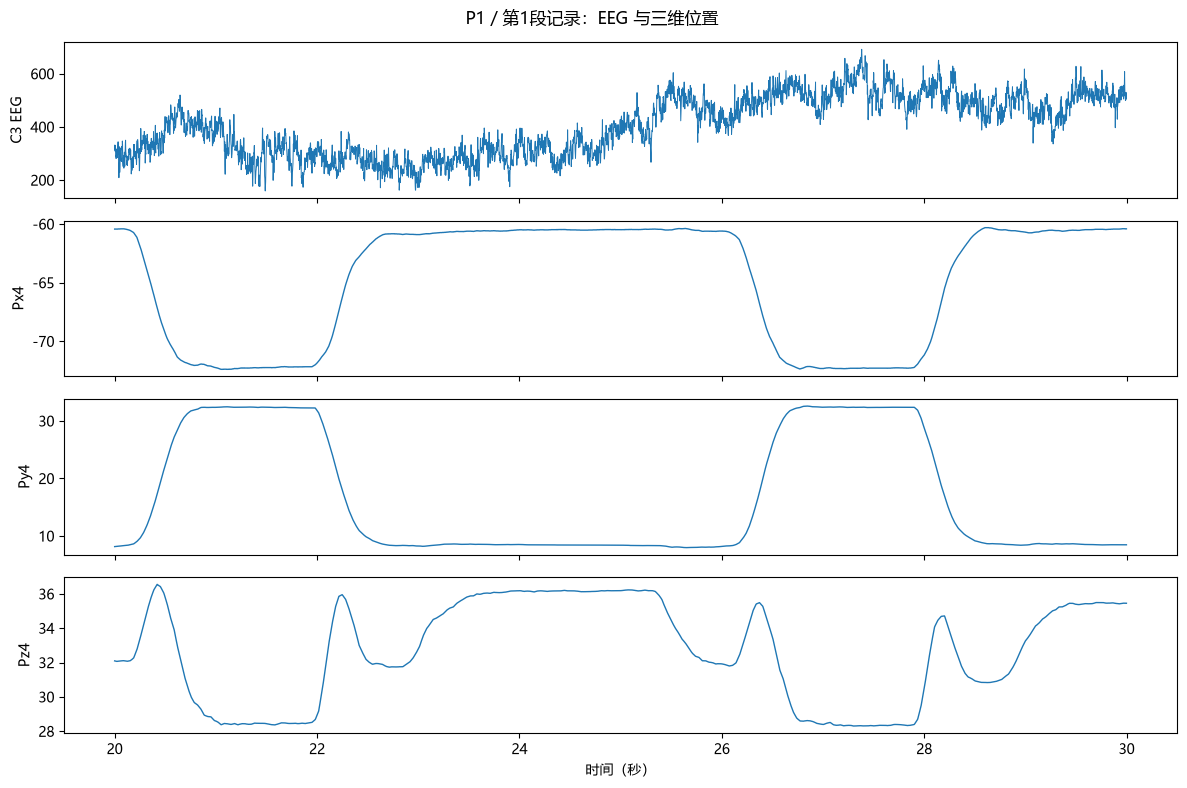

In [6]:
fs = int(hs.eeg.samplingrate)
start, stop = 20 * fs, 30 * fs
time = np.arange(start, stop) / fs

c3 = eeg_names.index("C3")
position_cols = [
    next(i for i, n in enumerate(kin_names) if str(n).startswith(name + " "))
    for name in ("Px4", "Py4", "Pz4")
]

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axes[0].plot(time, hs.eeg.sig[start:stop, c3], linewidth=0.7)
axes[0].set_ylabel("C3 EEG")

for ax, col, name in zip(axes[1:], position_cols, ("Px4", "Py4", "Pz4")):
    ax.plot(time, hs.kin.sig[start:stop, col], linewidth=1)
    ax.set_ylabel(name)

axes[-1].set_xlabel("时间（秒）")
fig.suptitle("P1 / 第1段记录：EEG 与三维位置")
plt.tight_layout()
plt.show()

试次起点（在整段记录中的秒数）： 21.572000000000003
LEDOn ： 2.0 秒（相对试次起点）
tHandStart ： 2.39 秒（相对试次起点）
tLiftOff ： 3.2840000000000003 秒（相对试次起点）
LEDOff ： 5.515999999999998 秒（相对试次起点）
tReplace ： 6.256 秒（相对试次起点）


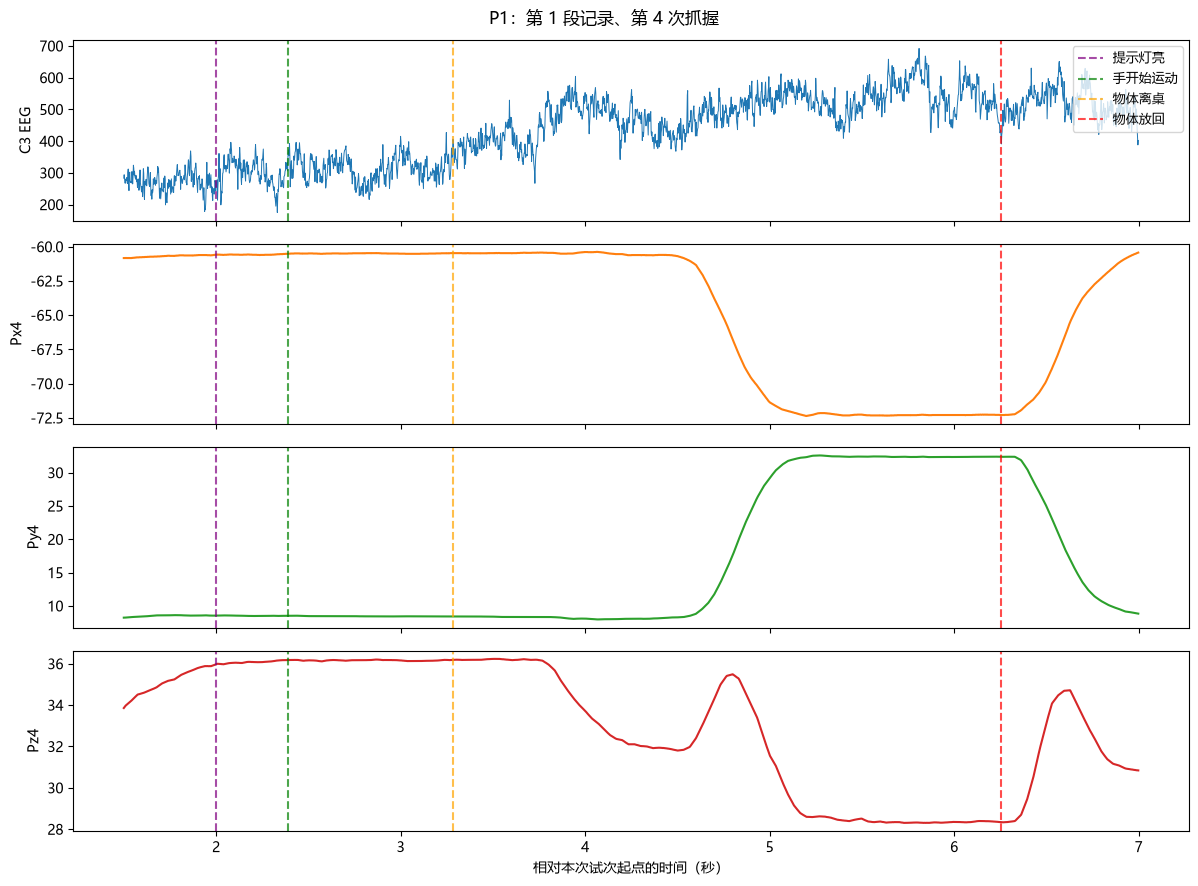

In [7]:
# 读取每次抓握的时间标记
P = loadmat(
    data_dir / "P1_AllLifts.mat",
    struct_as_record=False,
    squeeze_me=True
)["P"]

columns = list(P.ColNames)
run_col = columns.index("Run")
lift_col = columns.index("Lift")

# 选择第 1 段记录中的第 4 次抓握
rows = P.AllLifts[
    (P.AllLifts[:, run_col] == 1) &
    (P.AllLifts[:, lift_col] == 4)
]
trial = dict(zip(columns, rows[0]))

print("试次起点（在整段记录中的秒数）：", trial["StartTime"])
for name in ("LEDOn", "tHandStart", "tLiftOff", "LEDOff", "tReplace"):
    print(name, "：", trial[name], "秒（相对试次起点）")

# 截取这一次试验；横轴改为“距离本次试次起点的时间”
trial_start = trial["StartTime"]
i0 = round((trial_start + 1.5) * fs)
i1 = round((trial_start + 7.0) * fs)
t = np.arange(i0, i1) / fs - trial_start

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, hs.eeg.sig[i0:i1, c3], color="tab:blue", linewidth=0.7)
axes[0].set_ylabel("C3 EEG")

for ax, col, name, color in zip(
    axes[1:], position_cols, ("Px4", "Py4", "Pz4"),
    ("tab:orange", "tab:green", "tab:red")
):
    ax.plot(t, hs.kin.sig[i0:i1, col], color=color)
    ax.set_ylabel(name)

events = {
    "提示灯亮": ("LEDOn", "purple"),
    "手开始运动": ("tHandStart", "green"),
    "物体离桌": ("tLiftOff", "orange"),
    "物体放回": ("tReplace", "red"),
}
for label, (field, color) in events.items():
    event_time = trial[field]
    if np.isfinite(event_time):
        for ax in axes:
            ax.axvline(event_time, color=color, linestyle="--",
                       alpha=0.7, label=label if ax is axes[0] else None)

axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("相对本次试次起点的时间（秒）")
fig.suptitle("P1：第 1 段记录、第 4 次抓握")
plt.tight_layout()
plt.show()

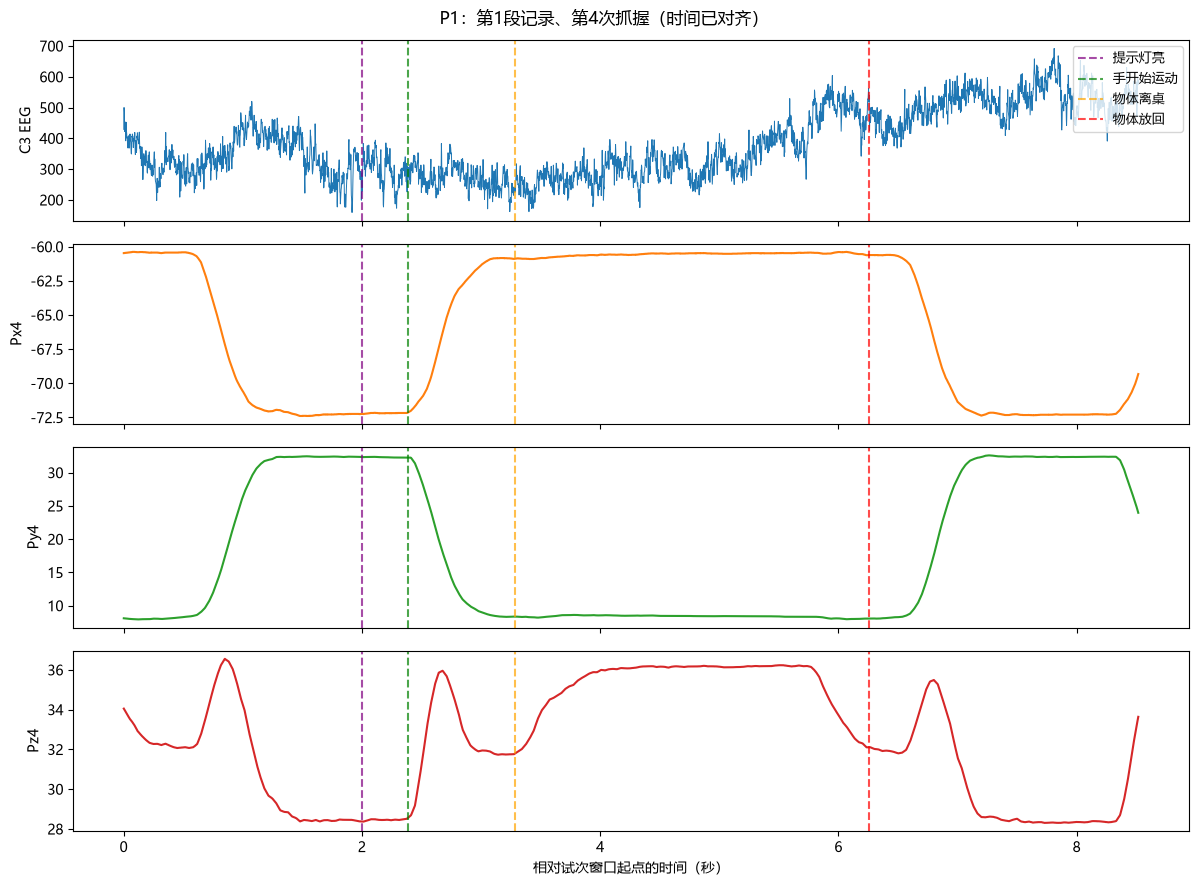

In [8]:
# 第1段记录中的第4次抓握：直接读取已经切好的试次窗口
ws = loadmat(
    data_dir / "WS_P1_S1.mat",
    struct_as_record=False,
    squeeze_me=True
)["ws"]
win = ws.win[3]  # Python 从0计数，所以第4次是索引3
t = np.asarray(win.eeg_t)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, win.eeg[:, c3], color="tab:blue", linewidth=0.7)
axes[0].set_ylabel("C3 EEG")

for ax, col, name, color in zip(
    axes[1:], position_cols, ("Px4", "Py4", "Pz4"),
    ("tab:orange", "tab:green", "tab:red")
):
    ax.plot(t, win.kin[:, col], color=color)
    ax.set_ylabel(name)

events = {
    "提示灯亮": ("LEDOn", "purple"),
    "手开始运动": ("tHandStart", "green"),
    "物体离桌": ("tLiftOff", "orange"),
    "物体放回": ("tReplace", "red"),
}
for label, (field, color) in events.items():
    event_time = trial[field]
    if np.isfinite(event_time):
        for ax in axes:
            ax.axvline(
                event_time, color=color, linestyle="--", alpha=0.7,
                label=label if ax is axes[0] else None
            )

axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("相对试次窗口起点的时间（秒）")
fig.suptitle("P1：第1段记录、第4次抓握（时间已对齐）")
plt.tight_layout()
plt.show()

EEG 输入 X： (150, 32)
手腕轨迹 Y： (500, 3)


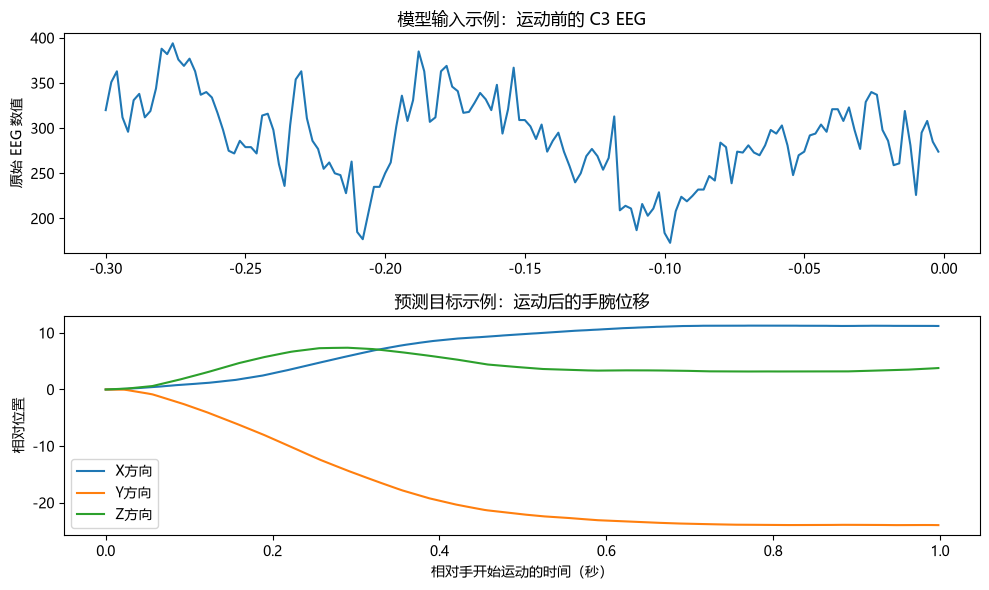

In [9]:
# 示例窗口：运动前 0.3 秒 EEG，预测运动后 1.0 秒手腕轨迹
# 这是入门检查用的窗口长度，还不是论文最终参数
onset = float(trial["tHandStart"])
onset_idx = np.searchsorted(win.eeg_t, onset)

n_before = round(0.3 * fs)  # 150 个采样点
n_after = round(1.0 * fs)   # 500 个采样点

X = win.eeg[onset_idx - n_before:onset_idx, :]          # EEG：时间 × 32通道
Y = win.kin[onset_idx:onset_idx + n_after, position_cols]  # 手腕：时间 × 3坐标
Y_relative = Y - Y[0]  # 相对于运动开始位置的位移，便于看轨迹

print("EEG 输入 X：", X.shape)
print("手腕轨迹 Y：", Y.shape)

t_in = win.eeg_t[onset_idx - n_before:onset_idx] - onset
t_out = win.eeg_t[onset_idx:onset_idx + n_after] - onset

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(t_in, X[:, c3])
axes[0].set_title("模型输入示例：运动前的 C3 EEG")
axes[0].set_ylabel("原始 EEG 数值")

axes[1].plot(t_out, Y_relative)
axes[1].set_title("预测目标示例：运动后的手腕位移")
axes[1].set_xlabel("相对手开始运动的时间（秒）")
axes[1].set_ylabel("相对位置")
axes[1].legend(["X方向", "Y方向", "Z方向"])
plt.tight_layout()
plt.show()

In [10]:
X_list, Y_list, kept_lifts = [], [], []

run1_rows = P.AllLifts[P.AllLifts[:, run_col] == 1]

for row in run1_rows:
    lift_number = int(row[lift_col])
    current_win = ws.win[lift_number - 1]
    onset = row[columns.index("tHandStart")]

    if not np.isfinite(onset):
        continue

    idx = np.searchsorted(current_win.eeg_t, onset)
    if idx < n_before or idx + n_after > len(current_win.eeg_t):
        continue

    eeg_part = current_win.eeg[idx - n_before:idx, :]
    wrist_part = current_win.kin[idx:idx + n_after, position_cols]
    wrist_part = wrist_part - wrist_part[0]

    if not np.isfinite(eeg_part).all() or not np.isfinite(wrist_part).all():
        continue

    X_list.append(eeg_part)
    Y_list.append(wrist_part)
    kept_lifts.append(lift_number)

X_batch = np.stack(X_list)
Y_batch = np.stack(Y_list)

print("保留的试次：", len(kept_lifts))
print("EEG 数据形状：", X_batch.shape)
print("真实手腕轨迹形状：", Y_batch.shape)

保留的试次： 34
EEG 数据形状： (34, 150, 32)
真实手腕轨迹形状： (34, 500, 3)


EEG 是否全为有限数值： True
轨迹是否全为有限数值： True
EEG 数值范围： -5108.0 到 9678.0


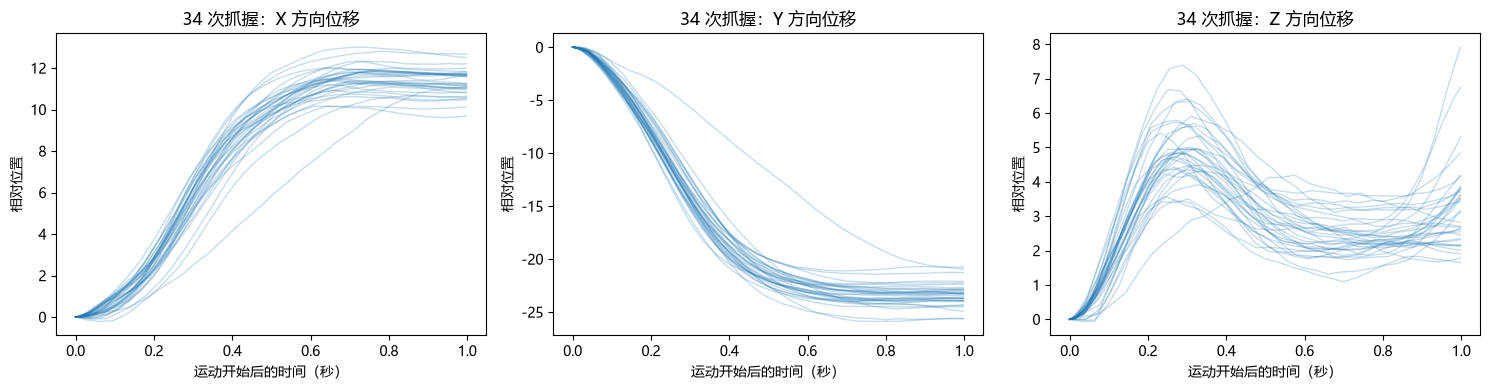

In [11]:
print("EEG 是否全为有限数值：", np.isfinite(X_batch).all())
print("轨迹是否全为有限数值：", np.isfinite(Y_batch).all())
print("EEG 数值范围：", X_batch.min(), "到", X_batch.max())

time_after = np.arange(Y_batch.shape[1]) / fs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, name in enumerate(("X", "Y", "Z")):
    axes[j].plot(time_after, Y_batch[:, :, j].T,
                 color="tab:blue", alpha=0.25, linewidth=1)
    axes[j].set_title(f"34 次抓握：{name} 方向位移")
    axes[j].set_xlabel("运动开始后的时间（秒）")
    axes[j].set_ylabel("相对位置")

plt.tight_layout()
plt.show()

第4次抓握，C3通道前10个EEG数值：
[320. 351. 363. 312. 296. 331. 338. 312. 319. 344.]


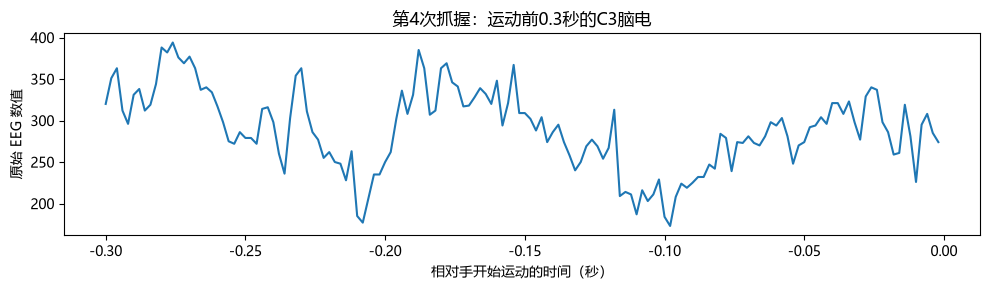

In [12]:
i = 3  # 第4次抓握；Python 从0计数
print("第4次抓握，C3通道前10个EEG数值：")
print(X_batch[i, :10, c3])

t_before = np.arange(X_batch.shape[1]) / fs - 0.3
plt.figure(figsize=(10, 3))
plt.plot(t_before, X_batch[i, :, c3])
plt.xlabel("相对手开始运动的时间（秒）")
plt.ylabel("原始 EEG 数值")
plt.title("第4次抓握：运动前0.3秒的C3脑电")
plt.tight_layout()
plt.show()

第23次抓握 | 通道 T8 | 数值 9678 | 距运动开始 -0.178 秒
第24次抓握 | 通道 T8 | 数值 -5108 | 距运动开始 -0.036 秒
第25次抓握 | 通道 T8 | 数值 -3059 | 距运动开始 -0.296 秒
第14次抓握 | 通道 F8 | 数值 -1946 | 距运动开始 -0.162 秒
第26次抓握 | 通道 TP9 | 数值 -1486 | 距运动开始 -0.158 秒


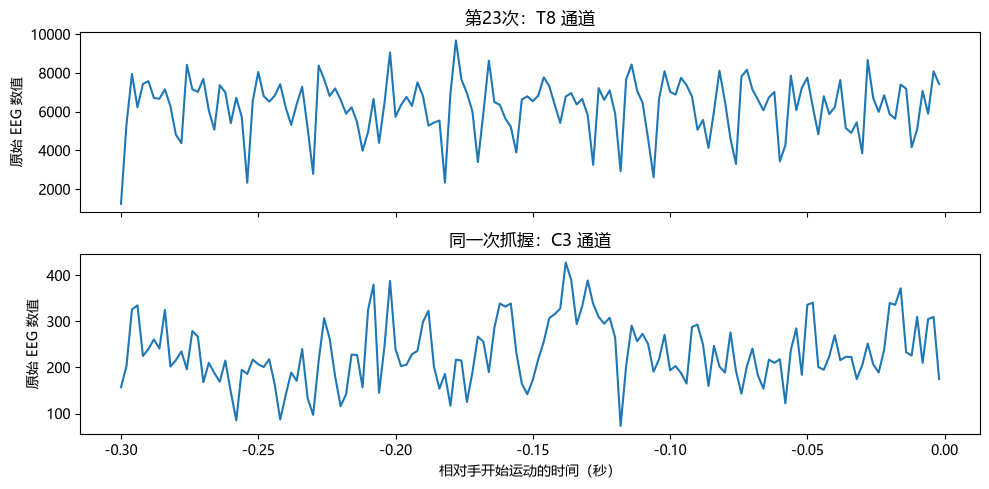

In [13]:
# 找出每次抓握中绝对值最大的 EEG 采样点
peak_per_trial = np.max(np.abs(X_batch), axis=(1, 2))
top_indices = np.argsort(peak_per_trial)[::-1][:5]

for i in top_indices:
    time_idx, channel_idx = np.unravel_index(
        np.argmax(np.abs(X_batch[i])), X_batch[i].shape
    )
    print(
        f"第{kept_lifts[i]}次抓握 | "
        f"通道 {eeg_names[channel_idx]} | "
        f"数值 {X_batch[i, time_idx, channel_idx]:.0f} | "
        f"距运动开始 {(time_idx - n_before) / fs:.3f} 秒"
    )

# 把异常最大的通道与 C3 放在一起查看
i = int(top_indices[0])
_, channel_idx = np.unravel_index(
    np.argmax(np.abs(X_batch[i])), X_batch[i].shape
)
t = np.arange(n_before) / fs - n_before / fs

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, X_batch[i, :, channel_idx])
axes[0].set_title(f"第{kept_lifts[i]}次：{eeg_names[channel_idx]} 通道")
axes[0].set_ylabel("原始 EEG 数值")

axes[1].plot(t, X_batch[i, :, c3])
axes[1].set_title("同一次抓握：C3 通道")
axes[1].set_xlabel("相对手开始运动的时间（秒）")
axes[1].set_ylabel("原始 EEG 数值")
plt.tight_layout()
plt.show()

In [14]:
trial_idx, time_idx, channel_idx = np.unravel_index(
    np.argmin(X_batch), X_batch.shape
)

print("数值：", X_batch[trial_idx, time_idx, channel_idx])
print("抓握次数：", kept_lifts[trial_idx])
print("通道：", eeg_names[channel_idx])
print("距运动开始：", (time_idx - n_before) / fs, "秒")
print("数组索引：", trial_idx, time_idx, channel_idx)

数值： -5108.0
抓握次数： 24
通道： T8
距运动开始： -0.036 秒
数组索引： 23 132 15


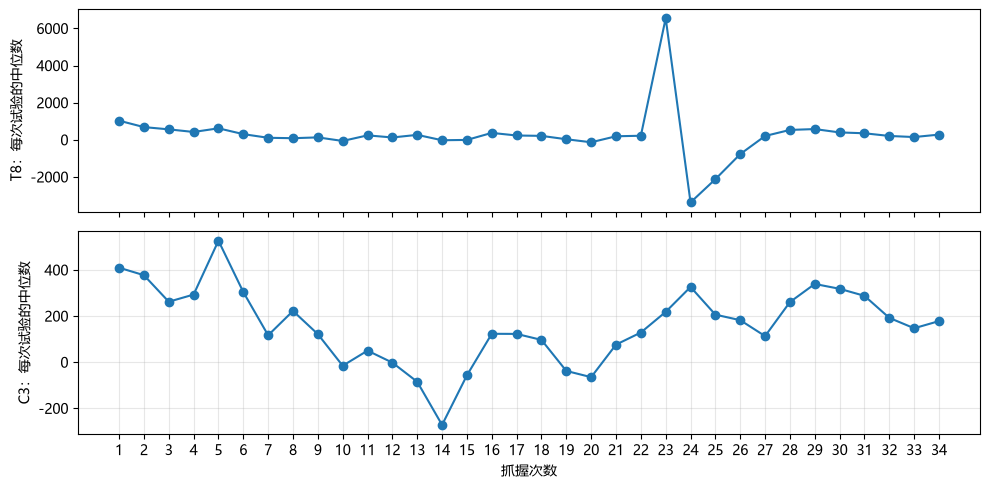

In [15]:
t8 = eeg_names.index("T8")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(kept_lifts, np.median(X_batch[:, :, t8], axis=1), "o-")
axes[0].set_ylabel("T8：每次试验的中位数")

axes[1].plot(kept_lifts, np.median(X_batch[:, :, c3], axis=1), "o-")
axes[1].set_ylabel("C3：每次试验的中位数")
axes[1].set_xlabel("抓握次数")
axes[1].set_xticks(kept_lifts)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


C3 通道：
第 4次：中位数=   293.0，波动范围=   221.0
第 5次：中位数=   526.5，波动范围=   262.0
第 6次：中位数=   304.0，波动范围=   284.0
第13次：中位数=   -85.0，波动范围=   234.0
第14次：中位数=  -272.0，波动范围=   297.0
第15次：中位数=   -57.0，波动范围=   216.0

T8 通道：
第22次：中位数=   217.0，波动范围=   767.0
第23次：中位数=  6550.5，波动范围=  8438.0
第24次：中位数= -3376.0，波动范围=  2829.0
第25次：中位数= -2123.5，波动范围=  1369.0
第26次：中位数=  -772.5，波动范围=   793.0


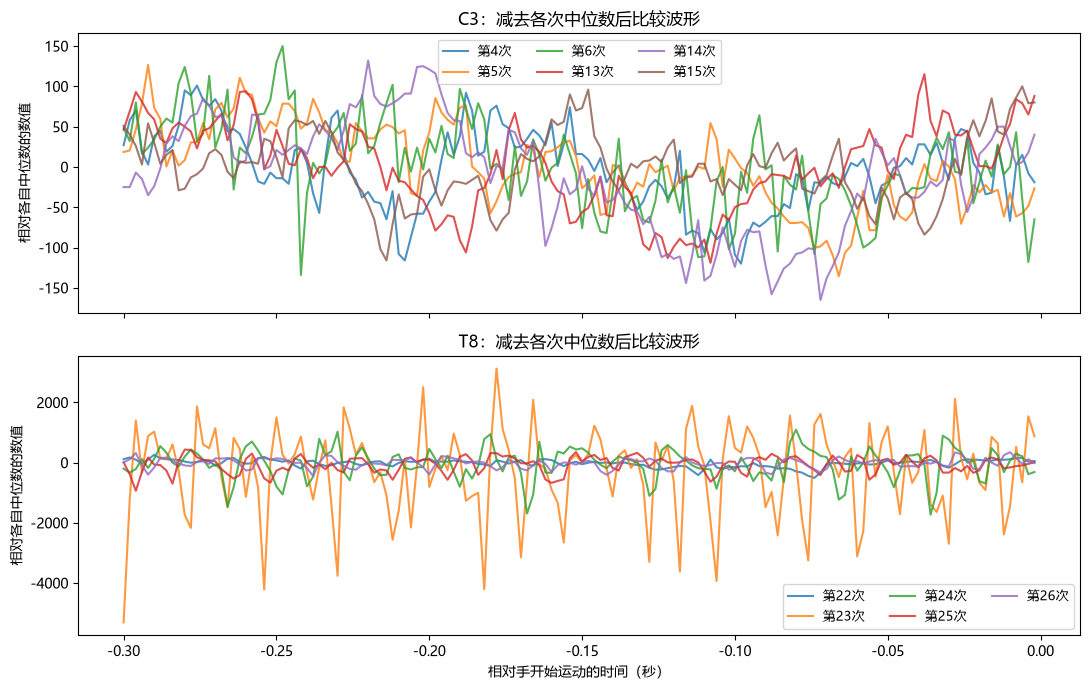

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t = np.arange(n_before) / fs - n_before / fs

checks = [
    ("C3", [4, 5, 6, 13, 14, 15]),
    ("T8", [22, 23, 24, 25, 26]),
]

for ax, (channel, lifts) in zip(axes, checks):
    ch = eeg_names.index(channel)
    print(f"\n{channel} 通道：")

    for lift in lifts:
        i = kept_lifts.index(lift)
        signal = X_batch[i, :, ch]
        median = np.median(signal)
        spread = np.ptp(signal)  # 片段最大值 - 最小值

        print(f"第{lift:2d}次：中位数={median:8.1f}，波动范围={spread:8.1f}")
        ax.plot(t, signal - median, label=f"第{lift}次", alpha=0.8)

    ax.set_title(f"{channel}：减去各次中位数后比较波形")
    ax.set_ylabel("相对各自中位数的数值")
    ax.legend(ncol=3, fontsize=9)

axes[-1].set_xlabel("相对手开始运动的时间（秒）")
plt.tight_layout()
plt.show()

In [17]:
paper_channels = [
    "F3", "Fz", "F4", "FC5", "FC1", "FC2", "FC6",
    "C3", "Cz", "C4", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "O1", "Oz", "O2"
]

paper_indices = [eeg_names.index(name) for name in paper_channels]
X21_preview = X_batch[:, :, paper_indices]

print("论文通道数：", len(paper_channels))
print("当前选通道后的形状：", X21_preview.shape)
print("是否包含 T8：", "T8" in paper_channels)

论文通道数： 21
当前选通道后的形状： (34, 150, 21)
是否包含 T8： False


滤波前： (32, 119496)
滤波后： (32, 119496)


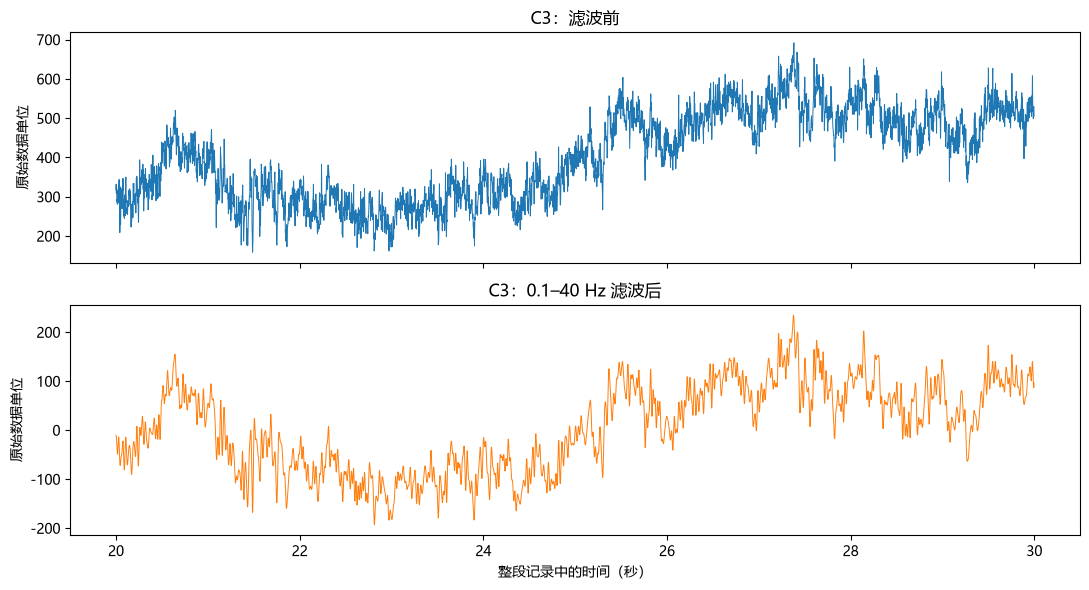

In [18]:
import mne

# HS 文件中的完整连续 EEG：原本是 时间点 × 32通道
eeg_continuous = hs.eeg.sig.T.astype(float)  # 改为 32通道 × 时间点

eeg_filtered = mne.filter.filter_data(
    eeg_continuous,
    sfreq=fs,
    l_freq=0.1,
    h_freq=40,
    method="fir",
    fir_design="firwin",
    phase="zero",
    verbose=False
)

print("滤波前：", eeg_continuous.shape)
print("滤波后：", eeg_filtered.shape)

# 先看同一段 C3：滤波前后对比
c3_idx = eeg_names.index("C3")
start, stop = 20 * fs, 30 * fs
time = np.arange(start, stop) / fs

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(time, eeg_continuous[c3_idx, start:stop], linewidth=0.7)
axes[0].set_title("C3：滤波前")

axes[1].plot(time, eeg_filtered[c3_idx, start:stop],
             linewidth=0.7, color="tab:orange")
axes[1].set_title("C3：0.1–40 Hz 滤波后")
axes[1].set_xlabel("整段记录中的时间（秒）")

for ax in axes:
    ax.set_ylabel("原始数据单位")
plt.tight_layout()
plt.show()

In [19]:
# eeg_filtered 是刚得到的完整连续记录，形状 (32, 119496)
eeg21_filtered = eeg_filtered[paper_indices, :].copy()

# 每个时间点，计算21个通道的平均值，再从各通道减去
reference = eeg21_filtered.mean(axis=0, keepdims=True)
eeg21_ref = eeg21_filtered - reference

print("重参考前：", eeg21_filtered.shape)
print("重参考后：", eeg21_ref.shape)
print("重参考后各时间点的通道均值最大偏差：",
      np.max(np.abs(eeg21_ref.mean(axis=0))))

重参考前： (21, 119496)
重参考后： (21, 119496)
重参考后各时间点的通道均值最大偏差： 9.473903143468003e-14


暂标记的坏通道： ['T8']
拟合出的 ICA 成分数： 30
准备排除的成分： []


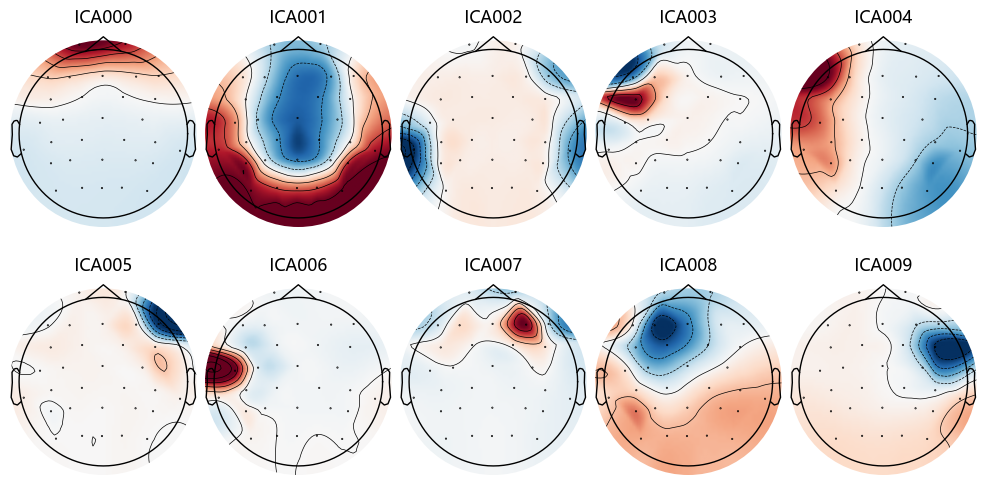

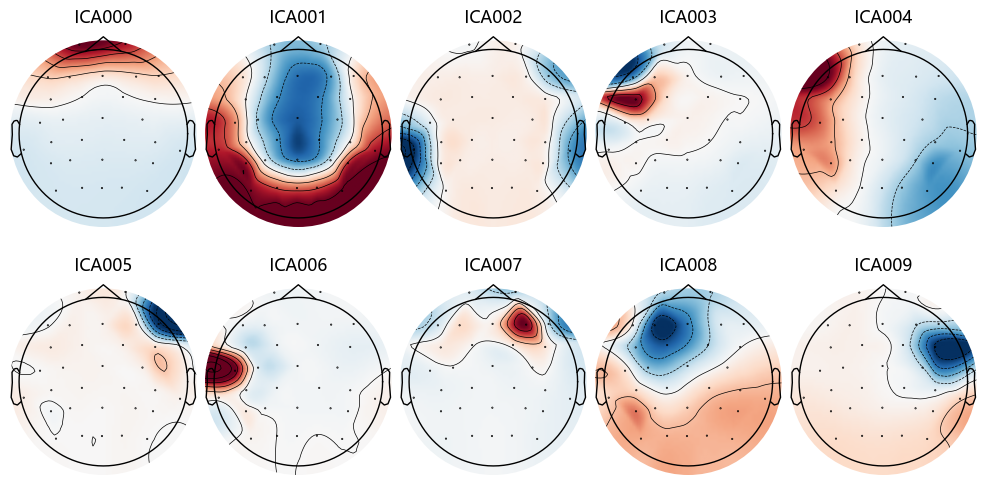

In [20]:
# 试运行假设：原始 EEG 数值单位为微伏，MNE 内部需要伏
# 正式复现前仍需核对数据单位
info = mne.create_info(eeg_names, sfreq=fs, ch_types="eeg")
raw32 = mne.io.RawArray(eeg_filtered * 1e-6, info, verbose=False)
raw32.set_montage("colin27_1020", on_missing="raise", verbose=False)

# 只对 P1 的 S1 暂时这样标记；不修改磁盘上的原始数据
raw32.info["bads"] = ["T8"]
raw_ref32 = raw32.copy().set_eeg_reference("average", verbose=False)

# ICA 拟合专用副本：1 Hz 高通有助于减轻慢漂移对拟合的干扰
raw_ica_fit = raw_ref32.copy().filter(
    l_freq=1.0, h_freq=None, picks="eeg", verbose=False
)

ica = mne.preprocessing.ICA(
    n_components=30,
    method="fastica",
    rng=97,
    max_iter=500
)
ica.fit(raw_ica_fit, picks="eeg", verbose=False)

print("暂标记的坏通道：", raw_ref32.info["bads"])
print("拟合出的 ICA 成分数：", ica.n_components_)
print("准备排除的成分：", ica.exclude)

ica.plot_components(picks=range(10))

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated


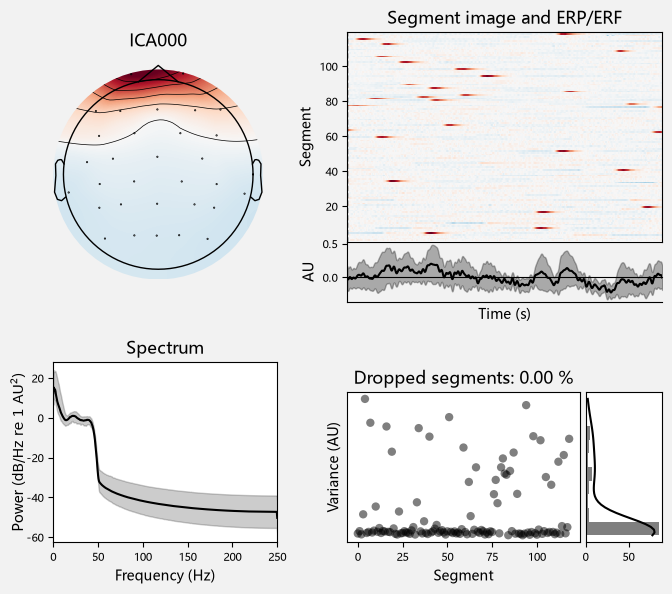

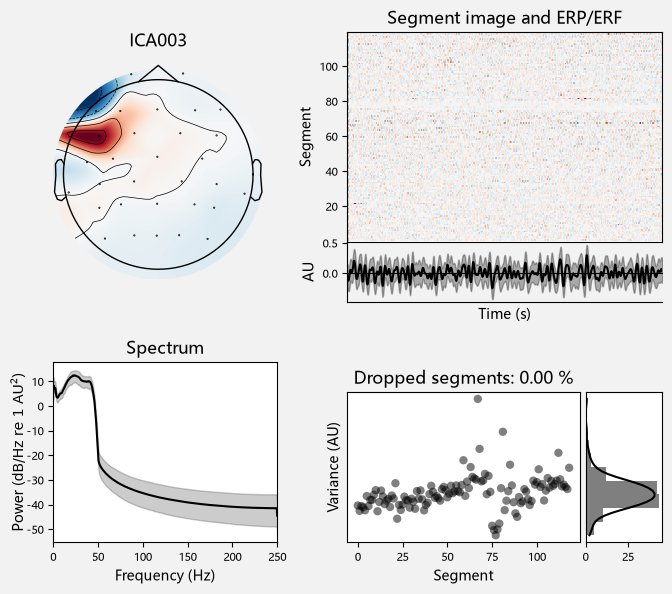

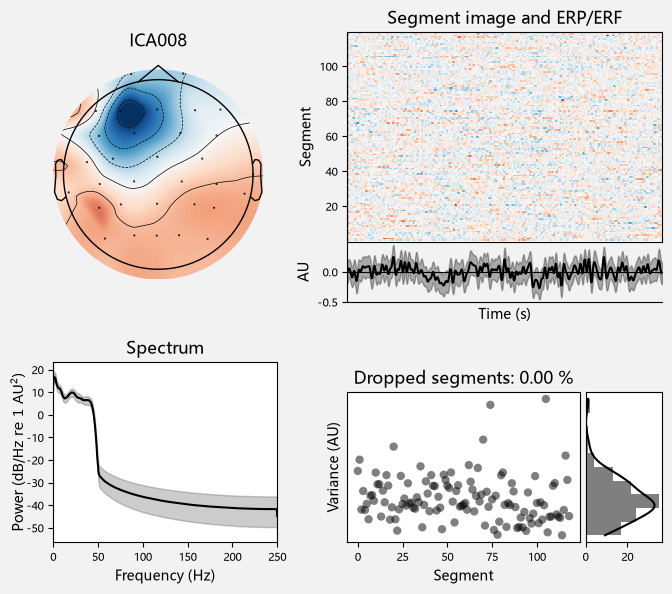

检查后当前排除列表： []


In [21]:
# 查看候选成分的头皮分布、时间变化和频谱
ica.plot_properties(
    raw_ica_fit,
    picks=[0, 3, 8]
)

print("检查后当前排除列表：", ica.exclude)